In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
graph = {
    'A': [('B', 1), ('C', 3)],
    'B': [('D', 3), ('E', 1)],
    'C': [('F', 5)],
    'D': [('G', 3)],
    'E': [('G', 1)],
    'F': [('G', 2)],
    'G': []
}

In [4]:
heuristic = {
    'A': 7, 'B': 6, 'C': 5, 'D': 3,
    'E': 1, 'F': 2, 'G': 0
}


In [5]:
import heapq

def A_st(graph, heuristic, start, goal):
    pq = [(heuristic[start], 0, start, [start])]
    visited = set()
    while pq:
        f, g, node, path = heapq.heappop(pq)
        if node == goal:
            return path, g
        if node in visited:
            continue
        visited.add(node)
        for neighbor, cost in graph[node]:
            new_g = g + cost
            new_f = new_g + heuristic[neighbor]
            heapq.heappush(pq, (new_f, new_g, neighbor, path + [neighbor]))
    return None, float('inf')

In [6]:
path, cost = A_st(graph, heuristic, 'A', 'G')
print(f"Path: {path}, Cost: {cost}")

Path: ['A', 'B', 'E', 'G'], Cost: 3


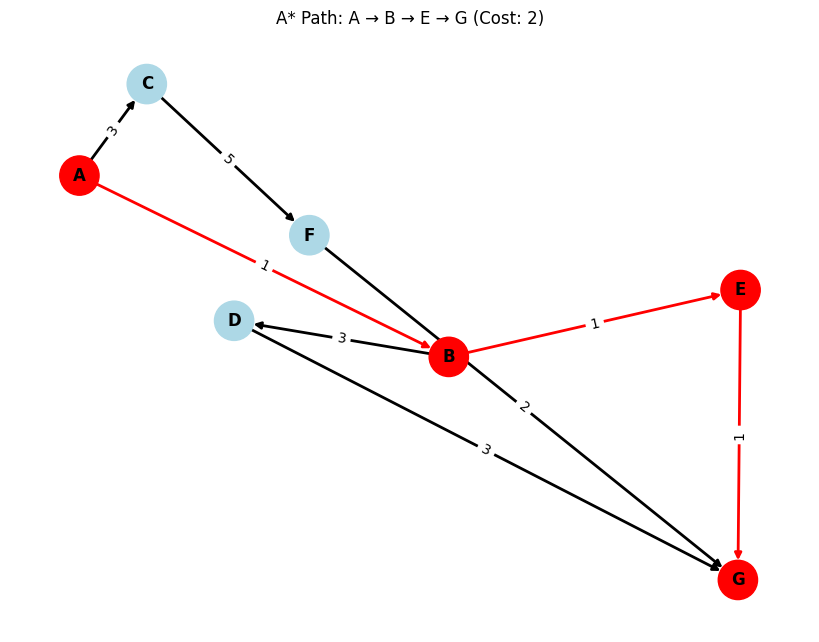

In [7]:
G = nx.DiGraph()
for node, edges in graph.items():
    for neighbor, cost in edges:
        G.add_edge(node, neighbor, weight=cost)

pos = nx.spring_layout(G, seed=42)
edge_labels = nx.get_edge_attributes(G, 'weight')

node_colors = ['red' if n in path else 'lightblue' for n in G.nodes()]
edge_colors = ['red' if (u, v) in zip(path, path[1:]) else 'black' for u, v in G.edges()]

plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=800,
        font_size=12, font_weight='bold', edge_color=edge_colors, width=2)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title(f"A* Path: {' → '.join(path)} (Cost: {cost})")
plt.show()

In [8]:
graph = {
    'A': {'type': 'OR', 'children': [('B', 1), ('C', 1)]},
    'B': {'type': 'AND', 'children': [('D', 1), ('E', 1)]},
    'C': {'type': 'OR', 'children': [('F', 1), ('G', 1)]},
    'D': {'type': 'LEAF', 'cost': 2},
    'E': {'type': 'LEAF', 'cost': 3},
    'F': {'type': 'LEAF', 'cost': 4},
    'G': {'type': 'LEAF', 'cost': 6}
}


In [9]:
def ao_star(node):
    info = graph[node]
    if info['type'] == 'LEAF':
        return info['cost'], [node]
    if info['type'] == 'OR':
        best_cost = float('inf')
        best_path = []
        for child, edge_cost in info['children']:
            child_cost, child_path = ao_star(child)
            total = edge_cost + child_cost
            if total < best_cost:  # fixed here
                best_cost = total
                best_path = [node] + child_path
        return best_cost, best_path

    if info['type'] == 'AND':
        total_cost = 0
        full_path = [node]
        for child, edge_cost in info['children']:
            child_cost, child_path = ao_star(child)
            total_cost += edge_cost + child_cost
            full_path += child_path
        return total_cost, full_path

cost, path = ao_star('A')
print(f"Cost: {cost}, Path: {path}")

Cost: 6, Path: ['A', 'C', 'F']


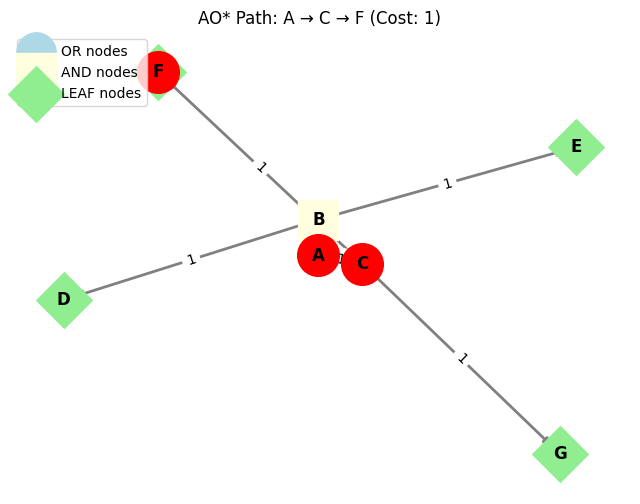

In [10]:
G = nx.DiGraph()
node_types = {}
for node, info in graph.items():
    node_types[node] = info['type']
    if info['type'] != 'LEAF':
        for child, cost in info['children']:
            G.add_edge(node, child, weight=cost)
pos = nx.spring_layout(G, seed=42)
node_colors = ['green' if n in path else 'lightgray' for n in G.nodes()]
or_nodes = [n for n, t in node_types.items() if t == 'OR']
and_nodes = [n for n, t in node_types.items() if t == 'AND']
leaf_nodes = [n for n, t in node_types.items() if t == 'LEAF']
edge_labels = nx.get_edge_attributes(G, 'weight')
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G, pos, nodelist=or_nodes, node_color='lightblue',
                       node_shape='o', node_size=800)
nx.draw_networkx_nodes(G, pos, nodelist=and_nodes, node_color='lightyellow',
                       node_shape='s', node_size=800)
nx.draw_networkx_nodes(G, pos, nodelist=leaf_nodes, node_color='lightgreen',
                       node_shape='D', node_size=800)
path_nodes = [n for n in path if n in G.nodes()]
nx.draw_networkx_nodes(G, pos, nodelist=path_nodes, node_color='red',
                       node_size=900)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, width=2)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title(f"AO* Path: {' → '.join(path)} (Cost: {cost})")
plt.legend(['OR nodes', 'AND nodes', 'LEAF nodes'], loc='upper left')
plt.axis('off')
plt.show()